

# Mixture Of Experts



## Hierarchical Mixture of Experts (HME)
**What HME is:**
- A tree of gating networks and experts
- Soft, learned routing (no hard rules)
- Experts represent capacity, not labels

**What this section implements:**
- Root gate with 3 branches
- Each branch has 5 experts (total 15)
- Experts specialize implicitly via routing
- Training includes anti-collapse regularization
- Diagnostics are logged to analyze expert specialization
- Goal: learn multiple conditional functions instead of one global regressor


### HME setup & imports
Set up paths, artifacts, and shared imports. This section reuses the baseline encoder sizes and existing device/seed from the notebook.

In [1]:
print("="*100)
print("SECTION XX: HIERARCHICAL MIXTURE OF EXPERTS (3 x 5)")
print("="*100)

import sys
import json
import math
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# -----------------------------
# Paths + artifacts
# -----------------------------
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from models.encoders import SharedTabularEncoder

ARTIFACT_ROOT = NOTEBOOK_DIR / "artifacts" / "hme_3x5"
CHECKPOINTS_DIR = ARTIFACT_ROOT / "checkpoints"
HISTORIES_DIR = ARTIFACT_ROOT / "training_histories"
PREDICTIONS_DIR = ARTIFACT_ROOT / "predictions"
PLOTS_DIR = ARTIFACT_ROOT / "plots"
SUMMARIES_DIR = ARTIFACT_ROOT / "summaries"

for d in [CHECKPOINTS_DIR, HISTORIES_DIR, PREDICTIONS_DIR, PLOTS_DIR, SUMMARIES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Use existing device if defined
if "device" in globals():
    _device = device
else:
    _device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Artifacts root: {ARTIFACT_ROOT}")
print(f"Using device: {_device}")

SECTION XX: HIERARCHICAL MIXTURE OF EXPERTS (3 x 5)
Artifacts root: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5
Using device: cpu


In [2]:
# Reproducibility
SEED = globals().get("SEED", 42)
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

def _seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)

dataloader_generator = torch.Generator()
dataloader_generator.manual_seed(SEED)

print(f"Reproducibility configured with SEED={SEED}")

Reproducibility configured with SEED=42


### Data hooks (reuse existing train/val tensors or loaders)
This section expects the *shared* feature tensors already prepared in this notebook. It will look for `train_loader`/`val_loader` first, then for shared arrays like `X_train_np`/`y_train_np` or `X_train`/`y_train`. Targets are assumed to be in log1p scale, consistent with the baseline.

In [3]:
def _to_tensor(x):
    if isinstance(x, np.ndarray):
        return torch.from_numpy(x)
    return x


def _concat_features(x_num, x_cat):
    x_num = _to_tensor(x_num)
    x_cat = _to_tensor(x_cat)
    if not torch.is_floating_point(x_num):
        x_num = x_num.float()
    if not torch.is_floating_point(x_cat):
        x_cat = x_cat.float()
    return torch.cat([x_num, x_cat], dim=1)


def _make_loaders_from_arrays(
    X_train_arr,
    y_train_arr,
    X_val_arr,
    y_val_arr,
    batch_size=256,
    num_workers=0,
    generator=None,
    worker_init_fn=None,
):
    X_train_arr = _to_tensor(X_train_arr)
    y_train_arr = _to_tensor(y_train_arr)
    X_val_arr = _to_tensor(X_val_arr)
    y_val_arr = _to_tensor(y_val_arr)

    train_ds = torch.utils.data.TensorDataset(X_train_arr, y_train_arr)
    val_ds = torch.utils.data.TensorDataset(X_val_arr, y_val_arr)
    train_loader_local = torch.utils.data.DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=num_workers,
        worker_init_fn=worker_init_fn,
        generator=generator,
    )
    val_loader_local = torch.utils.data.DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
        worker_init_fn=worker_init_fn,
        generator=generator,
    )
    return train_loader_local, val_loader_local


def _make_shared_loader_from_separate(
    loader,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    generator=None,
    worker_init_fn=None,
):
    xs, ys = [], []
    for batch in loader:
        if len(batch) == 3:
            x_num, x_cat, y = batch
        elif len(batch) == 2 and isinstance(batch[0], (tuple, list)):
            (x_num, x_cat), y = batch
        else:
            raise RuntimeError("Expected separate loader batches: (x_num, x_cat, y) or ((x_num, x_cat), y).")
        xs.append(_concat_features(x_num, x_cat))
        ys.append(_to_tensor(y))

    X_shared = torch.cat(xs, dim=0)
    y_shared = torch.cat(ys, dim=0)
    ds = torch.utils.data.TensorDataset(X_shared, y_shared)
    return torch.utils.data.DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False,
        num_workers=num_workers,
        worker_init_fn=worker_init_fn,
        generator=generator,
    )


NUM_WORKERS = globals().get("NUM_WORKERS", 0)
_loader_gen = globals().get("dataloader_generator", None)
_worker_init_fn = globals().get("_seed_worker", None)

if "train_loader" in globals() and "val_loader" in globals():
    _train_loader = train_loader
    _val_loader = val_loader
elif all(k in globals() for k in ["X_train_tensor", "y_train_tensor", "X_val_tensor", "y_val_tensor"]):
    BATCH_SIZE = globals().get("BATCH_SIZE", 256)
    _train_loader, _val_loader = _make_loaders_from_arrays(
        X_train_tensor,
        y_train_tensor,
        X_val_tensor,
        y_val_tensor,
        BATCH_SIZE,
        num_workers=NUM_WORKERS,
        generator=_loader_gen,
        worker_init_fn=_worker_init_fn,
    )
elif all(k in globals() for k in ["X_train_np", "y_train_np", "X_val_np", "y_val_np"]):
    BATCH_SIZE = globals().get("BATCH_SIZE", 256)
    _train_loader, _val_loader = _make_loaders_from_arrays(
        X_train_np,
        y_train_np,
        X_val_np,
        y_val_np,
        BATCH_SIZE,
        num_workers=NUM_WORKERS,
        generator=_loader_gen,
        worker_init_fn=_worker_init_fn,
    )
elif all(k in globals() for k in ["X_train", "y_train", "X_val", "y_val"]):
    BATCH_SIZE = globals().get("BATCH_SIZE", 256)
    _train_loader, _val_loader = _make_loaders_from_arrays(
        X_train,
        y_train,
        X_val,
        y_val,
        BATCH_SIZE,
        num_workers=NUM_WORKERS,
        generator=_loader_gen,
        worker_init_fn=_worker_init_fn,
    )
elif all(k in globals() for k in ["X_train_num", "X_train_cat", "y_train", "X_val_num", "X_val_cat", "y_val"]):
    BATCH_SIZE = globals().get("BATCH_SIZE", 256)
    X_train_shared = _concat_features(X_train_num, X_train_cat)
    X_val_shared = _concat_features(X_val_num, X_val_cat)
    _train_loader, _val_loader = _make_loaders_from_arrays(
        X_train_shared,
        y_train,
        X_val_shared,
        y_val,
        BATCH_SIZE,
        num_workers=NUM_WORKERS,
        generator=_loader_gen,
        worker_init_fn=_worker_init_fn,
    )
elif all(k in globals() for k in ["X_train_num_t", "X_train_cat_t", "y_train_t", "X_val_num_t", "X_val_cat_t", "y_val_t"]):
    BATCH_SIZE = globals().get("BATCH_SIZE", 256)
    X_train_shared = _concat_features(X_train_num_t, X_train_cat_t)
    X_val_shared = _concat_features(X_val_num_t, X_val_cat_t)
    _train_loader, _val_loader = _make_loaders_from_arrays(
        X_train_shared,
        y_train_t,
        X_val_shared,
        y_val_t,
        BATCH_SIZE,
        num_workers=NUM_WORKERS,
        generator=_loader_gen,
        worker_init_fn=_worker_init_fn,
    )
else:
    # Fallback: load train/val from processed CSVs (no test set usage)
    data_dir = Path(globals().get("ALL_FEATURES_DIR", PROJECT_ROOT / "data" / "processed" / "all_features"))
    train_path = data_dir / "train.csv"
    val_path = data_dir / "val.csv"
    if not train_path.exists() or not val_path.exists():
        raise RuntimeError(
            "HME requires shared or separate train/val tensors or loaders. "
            "Provide shared X/y (train_loader/val_loader or X_train_np/y_train_np/X_val_np/y_val_np) "
            "or separate X_train_num/X_train_cat + y_train (and val equivalents)."
        )

    from data.encode_features import prepare_features

    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    # Use val_df as placeholder test_df to avoid touching the true test split.
    X_train_np, X_val_np, _X_unused, y_train_np, y_val_np, _y_unused, _artifacts = prepare_features(
        train_df, val_df, val_df
    )

    BATCH_SIZE = globals().get("BATCH_SIZE", 256)
    _train_loader, _val_loader = _make_loaders_from_arrays(
        X_train_np,
        y_train_np,
        X_val_np,
        y_val_np,
        BATCH_SIZE,
        num_workers=NUM_WORKERS,
        generator=_loader_gen,
        worker_init_fn=_worker_init_fn,
    )

first_batch = next(iter(_train_loader))
if isinstance(first_batch[0], (tuple, list)):
    BATCH_SIZE = globals().get("BATCH_SIZE", 256)
    _train_loader = _make_shared_loader_from_separate(
        _train_loader,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        generator=_loader_gen,
        worker_init_fn=_worker_init_fn,
    )
    _val_loader = _make_shared_loader_from_separate(
        _val_loader,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        generator=_loader_gen,
        worker_init_fn=_worker_init_fn,
    )
    first_batch = next(iter(_train_loader))

input_dim = first_batch[0].shape[1]
print(f"HME input_dim (shared): {input_dim}")

HME input_dim (shared): 12


### Model definition (Phase 1 HME 3×5, shared backbone)
- **Input:** shared tabular feature tensor used by the baseline.
- **Backbone:** `SharedTabularEncoder` MLP with layers 256 → 128 → 64, each `Linear` + `ReLU` + `Dropout(p=0.1)`.
- **Root gate:** `Linear(64 → 3)` followed by softmax.
- **Leaf gates:** 3 separate gates, each `Linear(64 → 5)` followed by softmax.
- **Experts:** 15 leaf experts, each `Linear(64 → 1)`.
- **Output:** weighted sum of expert means using $w = p_{root} \cdot p_{leaf}$.
- **Loss:** Gaussian mixture NLL + load-balance regularizer + entropy warmup; temperature annealed to 1.0.

In [4]:
class HierarchicalMoE(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128, 64), dropout=0.1, num_root=3, num_leaf=5):
        super().__init__()
        self.num_root = num_root
        self.num_leaf = num_leaf
        self.encoder = SharedTabularEncoder(input_dim=input_dim, hidden_dims=hidden_dims, dropout=dropout)
        embed_dim = hidden_dims[-1] if hidden_dims else input_dim

        self.root_gate = nn.Linear(embed_dim, num_root)
        self.leaf_gates = nn.ModuleList([nn.Linear(embed_dim, num_leaf) for _ in range(num_root)])
        self.experts = nn.ModuleList([nn.Linear(embed_dim, 1) for _ in range(num_root * num_leaf)])

    def forward(self, x, temperature=1.0, return_all=False):
        h = self.encoder(x)
        root_logits = self.root_gate(h)
        root_probs = torch.softmax(root_logits / temperature, dim=1)  # [B,3]

        leaf_probs_list = []
        mu_list = []
        for i in range(self.num_root):
            leaf_logits = self.leaf_gates[i](h)
            leaf_probs = torch.softmax(leaf_logits / temperature, dim=1)  # [B,5]
            leaf_probs_list.append(leaf_probs)

            mu_branch = []
            for j in range(self.num_leaf):
                expert_idx = i * self.num_leaf + j
                mu = self.experts[expert_idx](h).squeeze(1)
                mu_branch.append(mu)
            mu_branch = torch.stack(mu_branch, dim=1)  # [B,5]
            mu_list.append(mu_branch)

        leaf_probs = torch.stack(leaf_probs_list, dim=1)  # [B,3,5]
        mu = torch.stack(mu_list, dim=1)  # [B,3,5]

        weights = root_probs.unsqueeze(2) * leaf_probs  # [B,3,5]
        weights_flat = weights.reshape(weights.shape[0], -1)  # [B,15]
        mu_flat = mu.reshape(mu.shape[0], -1)  # [B,15]

        y_hat = torch.sum(weights_flat * mu_flat, dim=1)

        if return_all:
            return y_hat, root_probs, leaf_probs, mu, weights_flat
        return y_hat


### Loss + anti-collapse regularization
We optimize a Gaussian mixture NLL (log1p target) plus load-balancing and entropy regularizers. Entropy is used only during warmup; temperature is annealed to 1.0.

In [5]:
def gaussian_mixture_nll(y, mu_flat, weights_flat, sigma=1.0, eps=1e-9):
    y = y.view(-1, 1)
    log_w = torch.log(weights_flat + eps)
    log_comp = -0.5 * ((y - mu_flat) / sigma) ** 2 - math.log(sigma * math.sqrt(2 * math.pi))
    log_mix = torch.logsumexp(log_w + log_comp, dim=1)
    return -torch.mean(log_mix)


def load_balance_loss(root_probs, leaf_probs, num_root=3, num_leaf=5):
    target_root = torch.full((num_root,), 1.0 / num_root, device=root_probs.device)
    root_mean = root_probs.mean(dim=0)
    root_loss = torch.mean((root_mean - target_root) ** 2)

    target_leaf = torch.full((num_leaf,), 1.0 / num_leaf, device=root_probs.device)
    leaf_losses = []
    for i in range(num_root):
        leaf_mean = leaf_probs[:, i, :].mean(dim=0)
        leaf_losses.append(torch.mean((leaf_mean - target_leaf) ** 2))

    return root_loss + torch.mean(torch.stack(leaf_losses))


def entropy_loss(root_probs, leaf_probs, eps=1e-9):
    root_ent = -torch.sum(root_probs * torch.log(root_probs + eps), dim=1).mean()
    leaf_ent = 0.0
    for i in range(leaf_probs.shape[1]):
        leaf_ent = leaf_ent + (-torch.sum(leaf_probs[:, i, :] * torch.log(leaf_probs[:, i, :] + eps), dim=1).mean())
    leaf_ent = leaf_ent / leaf_probs.shape[1]
    return -(root_ent + leaf_ent) / 2.0


### Training configuration
Hyperparameters mirror the baseline where possible. Temperature is annealed from 2.5 → 1.0, and entropy regularization linearly decays over a 20-epoch warmup.

In [6]:
EPOCHS = 100
LEARNING_RATE = globals().get("LEARNING_RATE", 1e-3)
WEIGHT_DECAY = globals().get("WEIGHT_DECAY", 1e-4)

NUM_ROOT = 3
NUM_LEAF = 5
TAU_START = 2.5
WARMUP_EPOCHS = 20
LAMBDA_BALANCE = 0.7
ENTROPY_WEIGHT = 0.01
SIGMA = 1.0

model = HierarchicalMoE(
    input_dim=input_dim,
    hidden_dims=(256, 128, 64),
    dropout=0.1,
    num_root=NUM_ROOT,
    num_leaf=NUM_LEAF,
).to(_device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

print(f"EPOCHS={EPOCHS}, LR={LEARNING_RATE}, WEIGHT_DECAY={WEIGHT_DECAY}")
print(f"Temp schedule: {TAU_START} → 1.0 | Warmup epochs: {WARMUP_EPOCHS}")


EPOCHS=100, LR=0.001, WEIGHT_DECAY=0.0001
Temp schedule: 2.5 → 1.0 | Warmup epochs: 20


### Hyperparameter selection rationale (early)
We choose $\tau_{start}$, $\lambda_{balance}$, and $\text{entropy\_weight}$ because they control **routing softness**, **load balancing across experts**, and **exploration during early training**. Instead of hand-picking, we run a small grid search on **validation only** and select the best configuration by **lowest validation MSE** (tie‑break with MAE).
The chosen configuration is then used for comparisons against the baseline and HME Phase 1/2 models (validation + test).

In [7]:
import time
import itertools
import gc

# -----------------------------
# Grid definition (easy to edit)
# -----------------------------
_DEFAULT_TAU = float(globals().get("TAU_START", 2.5))
_DEFAULT_LB = float(globals().get("LAMBDA_BALANCE", 0.1))
_DEFAULT_ENT = float(globals().get("ENTROPY_WEIGHT", 0.01))

TAU_GRID = sorted(set([_DEFAULT_TAU, 2.0, 2.5, 5.0]))
LAMBDA_BALANCE_GRID = sorted(set([_DEFAULT_LB, 0.1, 0.5, 1.0]))
ENTROPY_WEIGHT_GRID = sorted(set([_DEFAULT_ENT, 0.0, 0.01, 0.05]))

RESULTS_DIR = ARTIFACT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
GRID_CKPT_DIR = RESULTS_DIR / "grid_checkpoints"
GRID_CKPT_DIR.mkdir(parents=True, exist_ok=True)

GRID_JSON_PATH = RESULTS_DIR / "grid_search_results.json"
GRID_CSV_PATH = RESULTS_DIR / "grid_search_summary.csv"

print("Grid sizes:", len(TAU_GRID), len(LAMBDA_BALANCE_GRID), len(ENTROPY_WEIGHT_GRID))
print("TAU_GRID:", TAU_GRID)
print("LAMBDA_BALANCE_GRID:", LAMBDA_BALANCE_GRID)
print("ENTROPY_WEIGHT_GRID:", ENTROPY_WEIGHT_GRID)


def _set_seed(seed: int):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


def _format_run_name(tau, lb, ent):
    def _fmt(x):
        s = f"{x:.4g}"
        return s.replace(".", "p").replace("-", "m")
    return f"tau{_fmt(tau)}_lb{_fmt(lb)}_ent{_fmt(ent)}"


def run_experiment(tau_start, lambda_balance, entropy_weight, run_name, seed):
    start_time = time.time()
    _set_seed(seed)

    model = HierarchicalMoE(
        input_dim=input_dim,
        hidden_dims=(256, 128, 64),
        dropout=0.1,
        num_root=NUM_ROOT,
        num_leaf=NUM_LEAF,
    ).to(_device)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    history = {
        "epoch": [],
        "train_mse": [],
        "train_mae": [],
        "val_mse": [],
        "val_mae": [],
    }

    best_val_mse = float("inf")
    best_val_mae = float("inf")
    best_epoch = -1
    best_ckpt_path = None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tau = max(1.0, tau_start - (tau_start - 1.0) * (epoch - 1) / max(1, EPOCHS - 1))
        entropy_w = entropy_weight * max(0.0, 1.0 - (epoch - 1) / max(1, WARMUP_EPOCHS))

        train_mse_sum = 0.0
        train_mae_sum = 0.0
        n_train = 0

        for Xb, yb in _train_loader:
            Xb = Xb.to(_device)
            yb = yb.to(_device).view(-1)

            optimizer.zero_grad(set_to_none=True)
            y_hat, root_probs, leaf_probs, mu, weights_flat = model(Xb, temperature=tau, return_all=True)
            mu_flat = mu.reshape(mu.shape[0], -1)

            nll = gaussian_mixture_nll(yb, mu_flat, weights_flat, sigma=SIGMA)
            balance = load_balance_loss(root_probs, leaf_probs, num_root=NUM_ROOT, num_leaf=NUM_LEAF)
            ent = entropy_loss(root_probs, leaf_probs)
            loss = nll + lambda_balance * balance + entropy_w * ent
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            mse = torch.mean((y_hat - yb) ** 2)
            mae = torch.mean(torch.abs(y_hat - yb))

            bs = yb.shape[0]
            train_mse_sum += mse.item() * bs
            train_mae_sum += mae.item() * bs
            n_train += bs

        train_mse = train_mse_sum / max(1, n_train)
        train_mae = train_mae_sum / max(1, n_train)

        # Validation
        model.eval()
        val_mse_sum = 0.0
        val_mae_sum = 0.0
        n_val = 0

        with torch.no_grad():
            for Xb, yb in _val_loader:
                Xb = Xb.to(_device)
                yb = yb.to(_device).view(-1)
                y_hat, _, _, mu, weights_flat = model(Xb, temperature=1.0, return_all=True)
                mu_flat = mu.reshape(mu.shape[0], -1)

                _ = gaussian_mixture_nll(yb, mu_flat, weights_flat, sigma=SIGMA)
                mse = torch.mean((y_hat - yb) ** 2)
                mae = torch.mean(torch.abs(y_hat - yb))

                bs = yb.shape[0]
                val_mse_sum += mse.item() * bs
                val_mae_sum += mae.item() * bs
                n_val += bs

        val_mse = val_mse_sum / max(1, n_val)
        val_mae = val_mae_sum / max(1, n_val)

        history["epoch"].append(epoch)
        history["train_mse"].append(train_mse)
        history["train_mae"].append(train_mae)
        history["val_mse"].append(val_mse)
        history["val_mae"].append(val_mae)

        # Selection: val_mse primary, val_mae tie-break
        if (val_mse < best_val_mse) or (val_mse == best_val_mse and val_mae < best_val_mae):
            best_val_mse = val_mse
            best_val_mae = val_mae
            best_epoch = epoch
            best_ckpt_path = GRID_CKPT_DIR / f"{run_name}_best.pt"
            torch.save(
                {
                    "model_state": model.state_dict(),
                    "epoch": epoch,
                    "val_mse": val_mse,
                    "val_mae": val_mae,
                    "hyperparams": {
                        "tau_start": tau_start,
                        "lambda_balance": lambda_balance,
                        "entropy_weight": entropy_weight,
                    },
                    "seed": seed,
                },
                best_ckpt_path,
            )

    total_time = time.time() - start_time

    result = {
        "run_name": run_name,
        "hyperparams": {
            "tau_start": float(tau_start),
            "lambda_balance": float(lambda_balance),
            "entropy_weight": float(entropy_weight),
        },
        "seed": int(seed),
        "history": history,
        "best_epoch": int(best_epoch),
        "best_val_mse": float(best_val_mse),
        "best_val_mae": float(best_val_mae),
        "final_val_mse": float(history["val_mse"][-1]),
        "final_val_mae": float(history["val_mae"][-1]),
        "best_checkpoint_path": str(best_ckpt_path) if best_ckpt_path is not None else None,
        "total_time_sec": float(total_time),
    }

    # Cleanup
    del model, optimizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

    return result


# -----------------------------
# Run grid sweep
# -----------------------------
_BASE_SEED = int(globals().get("SEED", 42))

all_results = []
all_runs = list(itertools.product(TAU_GRID, LAMBDA_BALANCE_GRID, ENTROPY_WEIGHT_GRID))

for idx, (tau, lb, ent) in enumerate(all_runs, start=1):
    run_name = _format_run_name(tau, lb, ent)
    seed = _BASE_SEED + idx

    res = run_experiment(tau, lb, ent, run_name=run_name, seed=seed)
    all_results.append(res)

    print(
        f"[{idx}/{len(all_runs)}] {run_name} | "
        f"tau={tau}, lambda_balance={lb}, entropy_weight={ent} | "
        f"best_val_mse={res['best_val_mse']:.6f}, best_val_mae={res['best_val_mae']:.6f}"
    )

# Summary DataFrame
summary_rows = []
for r in all_results:
    row = {
        "run_name": r["run_name"],
        "tau_start": r["hyperparams"]["tau_start"],
        "lambda_balance": r["hyperparams"]["lambda_balance"],
        "entropy_weight": r["hyperparams"]["entropy_weight"],
        "seed": r["seed"],
        "best_epoch": r["best_epoch"],
        "best_val_mse": r["best_val_mse"],
        "best_val_mae": r["best_val_mae"],
        "final_val_mse": r["final_val_mse"],
        "final_val_mae": r["final_val_mae"],
        "best_checkpoint_path": r["best_checkpoint_path"],
        "total_time_sec": r["total_time_sec"],
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["best_val_mse", "best_val_mae"], ascending=[True, True]).reset_index(drop=True)

print("\nTop 5 configs by best_val_mse:")
print(summary_df.head(5))

# Save full results
with open(GRID_JSON_PATH, "w") as f:
    json.dump(all_results, f, indent=2)
summary_df.to_csv(GRID_CSV_PATH, index=False)

print(f"✓ Saved grid results to: {GRID_JSON_PATH}")
print(f"✓ Saved grid summary to: {GRID_CSV_PATH}")

# Report chosen config (selection rule: best_val_mse then best_val_mae)
best_cfg = summary_df.iloc[0]
print(
    "\nChosen config (best_val_mse, tie-break best_val_mae): "
    f"tau_start={best_cfg['tau_start']}, lambda_balance={best_cfg['lambda_balance']}, "
    f"entropy_weight={best_cfg['entropy_weight']} | "
    f"best_val_mse={best_cfg['best_val_mse']:.6f}, best_val_mae={best_cfg['best_val_mae']:.6f}"
)

# Persist chosen config for downstream comparisons
BEST_GRID_CFG = {
    "run_name": str(best_cfg["run_name"]),
    "tau_start": float(best_cfg["tau_start"]),
    "lambda_balance": float(best_cfg["lambda_balance"]),
    "entropy_weight": float(best_cfg["entropy_weight"]),
    "best_val_mse": float(best_cfg["best_val_mse"]),
    "best_val_mae": float(best_cfg["best_val_mae"]),
}
BEST_GRID_CKPT_PATH = Path(best_cfg["best_checkpoint_path"]) if pd.notna(best_cfg["best_checkpoint_path"]) else None
print(f"✓ BEST_GRID_CFG: {BEST_GRID_CFG}")
print(f"✓ BEST_GRID_CKPT_PATH: {BEST_GRID_CKPT_PATH}")

Grid sizes: 3 4 3
TAU_GRID: [2.0, 2.5, 5.0]
LAMBDA_BALANCE_GRID: [0.1, 0.5, 0.7, 1.0]
ENTROPY_WEIGHT_GRID: [0.0, 0.01, 0.05]
[1/36] tau2_lb0p1_ent0 | tau=2.0, lambda_balance=0.1, entropy_weight=0.0 | best_val_mse=1.074307, best_val_mae=0.758652
[2/36] tau2_lb0p1_ent0p01 | tau=2.0, lambda_balance=0.1, entropy_weight=0.01 | best_val_mse=1.098701, best_val_mae=0.784107
[3/36] tau2_lb0p1_ent0p05 | tau=2.0, lambda_balance=0.1, entropy_weight=0.05 | best_val_mse=1.142953, best_val_mae=0.801655
[4/36] tau2_lb0p5_ent0 | tau=2.0, lambda_balance=0.5, entropy_weight=0.0 | best_val_mse=1.055434, best_val_mae=0.754934
[5/36] tau2_lb0p5_ent0p01 | tau=2.0, lambda_balance=0.5, entropy_weight=0.01 | best_val_mse=1.094188, best_val_mae=0.770075
[6/36] tau2_lb0p5_ent0p05 | tau=2.0, lambda_balance=0.5, entropy_weight=0.05 | best_val_mse=1.060925, best_val_mae=0.760470
[7/36] tau2_lb0p7_ent0 | tau=2.0, lambda_balance=0.7, entropy_weight=0.0 | best_val_mse=1.055225, best_val_mae=0.756848
[8/36] tau2_lb0p7_e

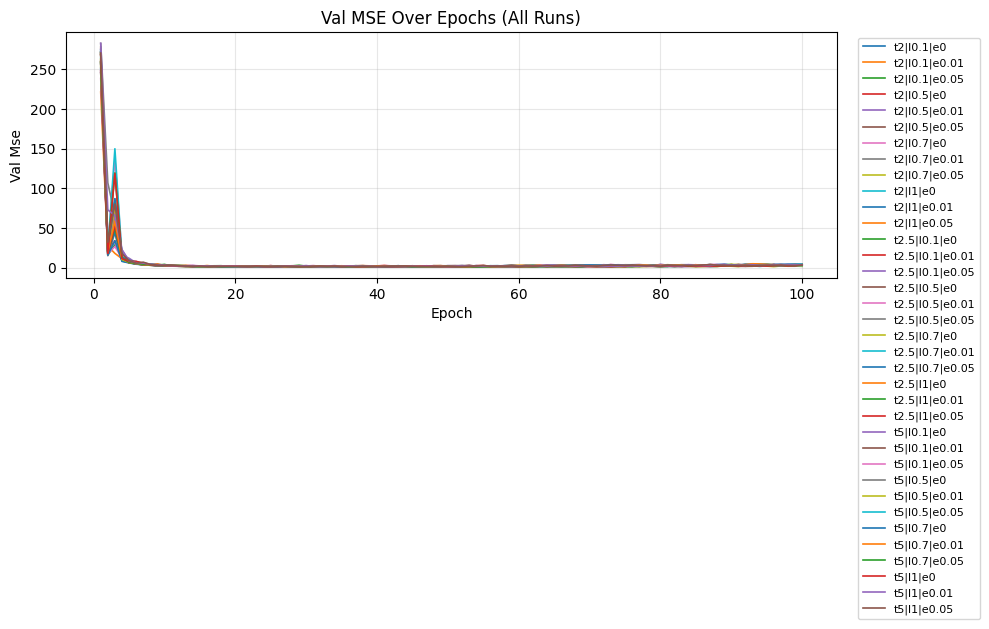

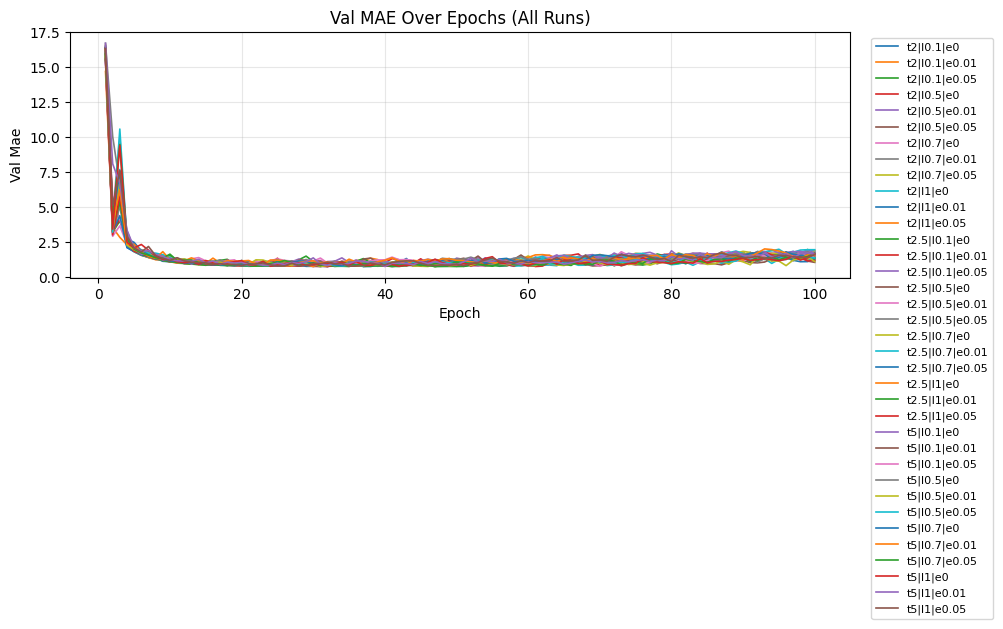

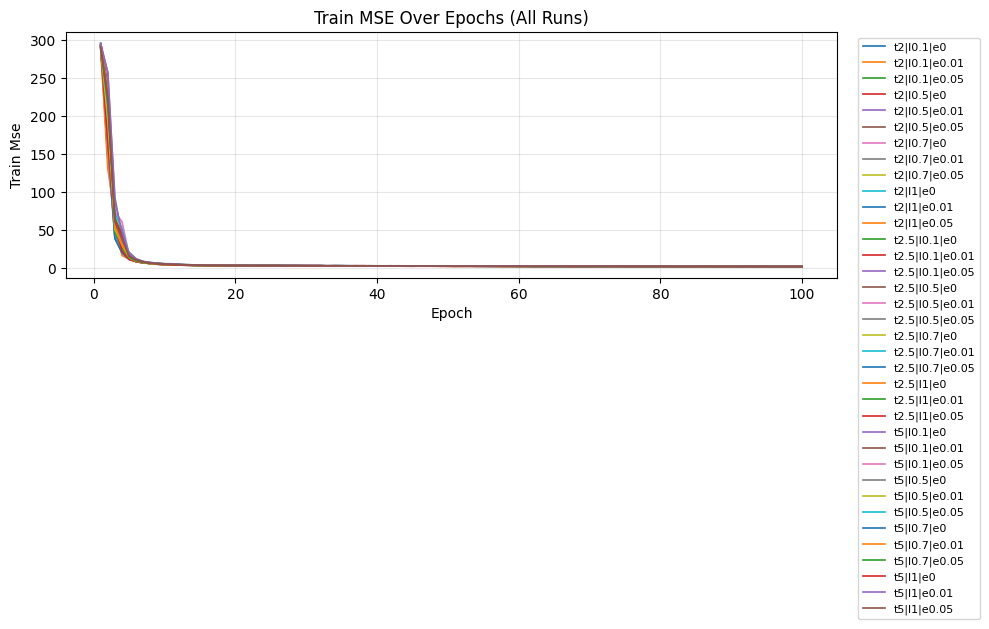

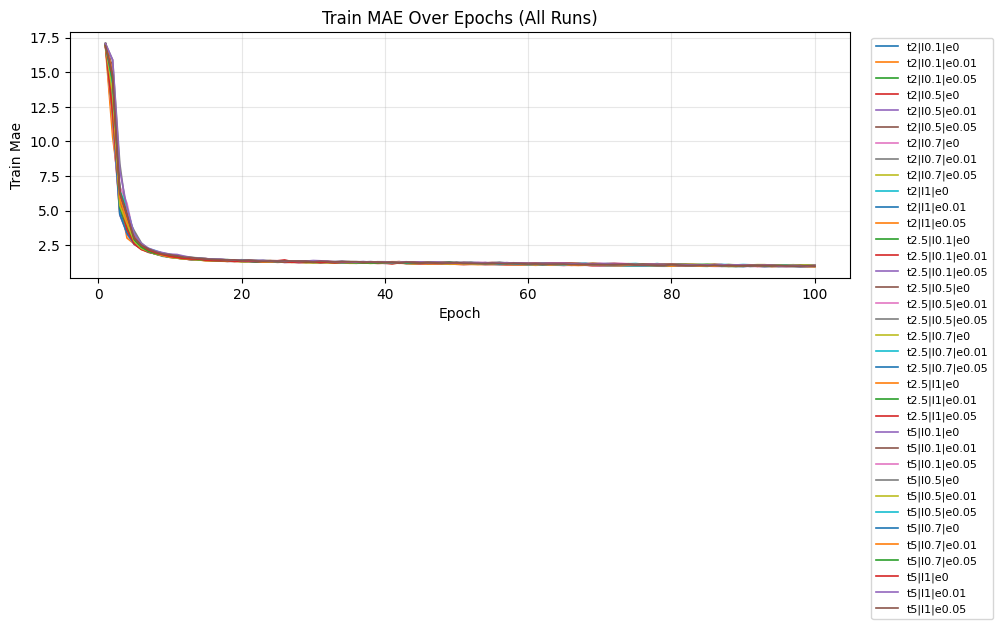

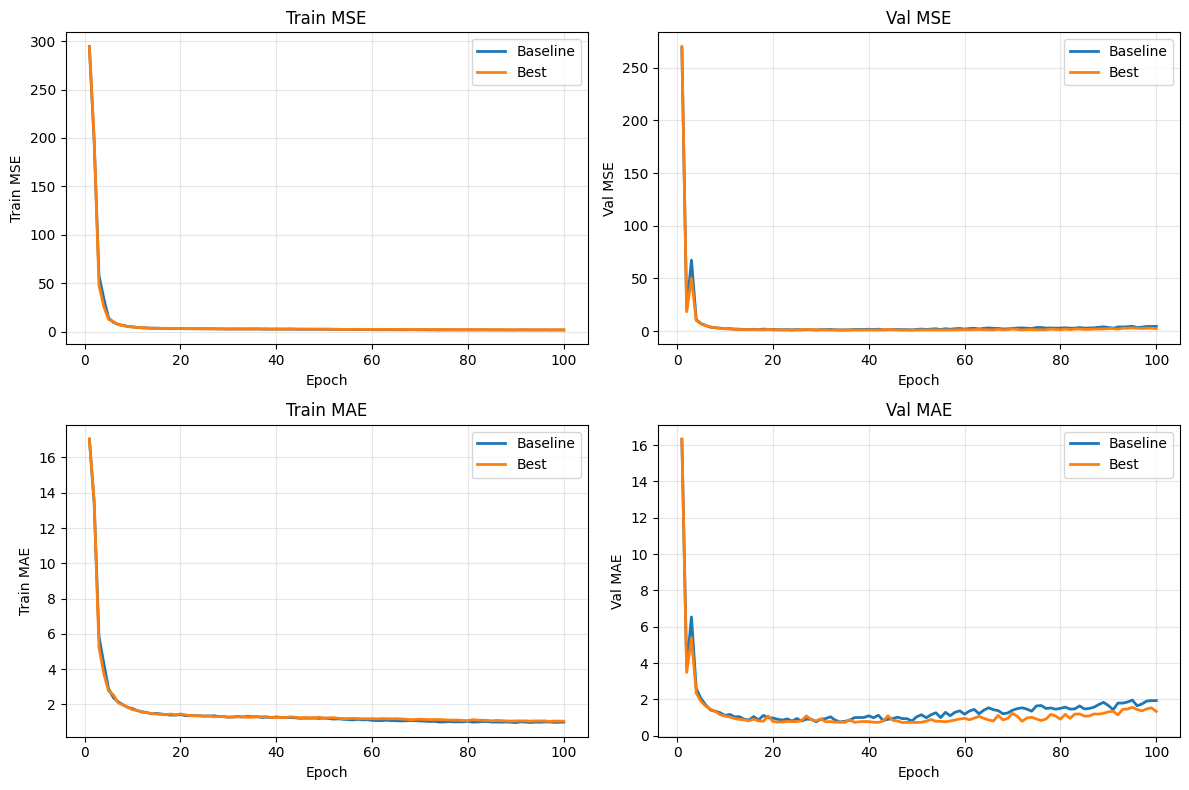

In [18]:
# -----------------------------
# Plots: overview, best vs baseline
# -----------------------------

# Build quick lookup by run_name
run_lookup = {r["run_name"]: r for r in all_results}

# Baseline = current default hyperparams from notebook
baseline_key = None
for r in all_results:
    hp = r["hyperparams"]
    if (
        float(hp["tau_start"]) == float(_DEFAULT_TAU)
        and float(hp["lambda_balance"]) == float(_DEFAULT_LB)
        and float(hp["entropy_weight"]) == float(_DEFAULT_ENT)
    ):
        baseline_key = r["run_name"]
        break

best_key = summary_df.iloc[0]["run_name"]

if baseline_key is None:
    print("⚠️  Baseline config not found in grid; using best config only for plots.")

# A) Overview plots for all runs

def _plot_overview(metric_name, title):
    plt.figure(figsize=(10, 5))
    for r in all_results:
        label = f"t{r['hyperparams']['tau_start']:g}|l{r['hyperparams']['lambda_balance']:g}|e{r['hyperparams']['entropy_weight']:g}"
        plt.plot(r["history"]["epoch"], r["history"][metric_name], label=label, linewidth=1.2)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric_name.replace("_", " ").title())
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()

_plot_overview("val_mse", "Val MSE Over Epochs (All Runs)")
_plot_overview("val_mae", "Val MAE Over Epochs (All Runs)")
_plot_overview("train_mse", "Train MSE Over Epochs (All Runs)")
_plot_overview("train_mae", "Train MAE Over Epochs (All Runs)")

# B) Best vs Baseline (2x2)
if baseline_key is not None:
    base = run_lookup[baseline_key]
    best = run_lookup[best_key]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    metrics = [("train_mse", "Train MSE"), ("val_mse", "Val MSE"), ("train_mae", "Train MAE"), ("val_mae", "Val MAE")]

    for ax, (m, title) in zip(axes.ravel(), metrics):
        ax.plot(base["history"]["epoch"], base["history"][m], label="Baseline", linewidth=2)
        ax.plot(best["history"]["epoch"], best["history"][m], label="Best", linewidth=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

### Apply chosen hyperparameters (no grid rerun)
Load the best hyperparameters from the previous sweep (saved to disk) and reinitialize the Phase 1 model before training.

In [19]:
best_cfg_local = None

if "BEST_GRID_CFG" in globals():
    best_cfg_local = BEST_GRID_CFG
elif "GRID_CSV_PATH" in globals() and Path(GRID_CSV_PATH).exists():
    _grid_df = pd.read_csv(GRID_CSV_PATH)
    if len(_grid_df) > 0:
        best_cfg_local = {
            "tau_start": float(_grid_df.loc[0, "tau_start"]),
            "lambda_balance": float(_grid_df.loc[0, "lambda_balance"]),
            "entropy_weight": float(_grid_df.loc[0, "entropy_weight"]),
        }

if best_cfg_local is None:
    raise RuntimeError("Best hyperparameters not found. Run the grid sweep once or provide BEST_GRID_CFG.")

TAU_START = float(best_cfg_local["tau_start"])
LAMBDA_BALANCE = float(best_cfg_local["lambda_balance"])
ENTROPY_WEIGHT = float(best_cfg_local["entropy_weight"])

print(f"Using chosen hyperparameters: tau_start={TAU_START}, lambda_balance={LAMBDA_BALANCE}, entropy_weight={ENTROPY_WEIGHT}")

# Reinitialize Phase 1 model/optimizer with chosen hyperparameters
model = HierarchicalMoE(
    input_dim=input_dim,
    hidden_dims=(256, 128, 64),
    dropout=0.1,
    num_root=NUM_ROOT,
    num_leaf=NUM_LEAF,
).to(_device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

Using chosen hyperparameters: tau_start=2.5, lambda_balance=1.0, entropy_weight=0.01


### Train and validate
Optimize NLL on training set and track validation NLL/MSE/MAE. Best checkpoint is selected by validation NLL.

In [28]:
history = defaultdict(list)

best_val_nll = float("inf")
best_checkpoint_path = CHECKPOINTS_DIR / "hme_best.pt"

for epoch in range(1, EPOCHS + 1):
    model.train()
    tau = max(1.0, TAU_START - (TAU_START - 1.0) * (epoch - 1) / max(1, EPOCHS - 1))
    entropy_w = ENTROPY_WEIGHT * max(0.0, 1.0 - (epoch - 1) / max(1, WARMUP_EPOCHS))

    train_nll_sum = 0.0
    n_train = 0

    for Xb, yb in _train_loader:
        Xb = Xb.to(_device)
        yb = yb.to(_device).view(-1)

        optimizer.zero_grad(set_to_none=True)
        y_hat, root_probs, leaf_probs, mu, weights_flat = model(Xb, temperature=tau, return_all=True)
        mu_flat = mu.reshape(mu.shape[0], -1)

        nll = gaussian_mixture_nll(yb, mu_flat, weights_flat, sigma=SIGMA)
        balance = load_balance_loss(root_probs, leaf_probs, num_root=NUM_ROOT, num_leaf=NUM_LEAF)
        ent = entropy_loss(root_probs, leaf_probs)
        loss = nll + LAMBDA_BALANCE * balance + entropy_w * ent
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        bs = yb.shape[0]
        train_nll_sum += nll.item() * bs
        n_train += bs

    train_nll = train_nll_sum / max(1, n_train)

    # Validation
    model.eval()
    val_nll_sum = 0.0
    val_mse_sum = 0.0
    val_mae_sum = 0.0
    n_val = 0

    with torch.no_grad():
        for Xb, yb in _val_loader:
            Xb = Xb.to(_device)
            yb = yb.to(_device).view(-1)
            y_hat, root_probs, leaf_probs, mu, weights_flat = model(Xb, temperature=1.0, return_all=True)
            mu_flat = mu.reshape(mu.shape[0], -1)

            nll = gaussian_mixture_nll(yb, mu_flat, weights_flat, sigma=SIGMA)
            mse = torch.mean((y_hat - yb) ** 2)
            mae = torch.mean(torch.abs(y_hat - yb))

            bs = yb.shape[0]
            val_nll_sum += nll.item() * bs
            val_mse_sum += mse.item() * bs
            val_mae_sum += mae.item() * bs
            n_val += bs

    val_nll = val_nll_sum / max(1, n_val)
    val_mse = val_mse_sum / max(1, n_val)
    val_mae = val_mae_sum / max(1, n_val)

    history["epoch"].append(epoch)
    history["train_nll"].append(train_nll)
    history["val_nll"].append(val_nll)
    history["val_mse"].append(val_mse)
    history["val_mae"].append(val_mae)
    history["temperature"].append(tau)
    history["entropy_weight"].append(entropy_w)

    if val_nll < best_val_nll:
        best_val_nll = val_nll
        torch.save(
            {
                "model_state": model.state_dict(),
                "epoch": epoch,
                "val_nll": val_nll,
                "val_mse": val_mse,
                "val_mae": val_mae,
            },
            best_checkpoint_path,
        )

    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(
            f"Epoch {epoch:03d}/{EPOCHS} | "
            f"train_nll={train_nll:.4f} | val_nll={val_nll:.4f} | "
            f"val_mse={val_mse:.4f} | val_mae={val_mae:.4f} | "
            f"tau={tau:.2f}"
        )

print(f"\n✓ Best HME checkpoint saved to: {best_checkpoint_path}")


Epoch 001/100 | train_nll=1.8753 | val_nll=1.6221 | val_mse=1.4506 | val_mae=0.9663 | tau=2.50
Epoch 010/100 | train_nll=1.8532 | val_nll=1.6193 | val_mse=1.4046 | val_mae=0.9549 | tau=2.36
Epoch 020/100 | train_nll=1.8533 | val_nll=1.7264 | val_mse=1.8522 | val_mae=1.1395 | tau=2.21
Epoch 030/100 | train_nll=1.8273 | val_nll=1.7048 | val_mse=1.6702 | val_mae=1.0658 | tau=2.06
Epoch 040/100 | train_nll=1.8003 | val_nll=1.6709 | val_mse=1.5101 | val_mae=1.0036 | tau=1.91
Epoch 050/100 | train_nll=1.7726 | val_nll=1.7281 | val_mse=1.7927 | val_mae=1.1269 | tau=1.76
Epoch 060/100 | train_nll=1.7323 | val_nll=1.6227 | val_mse=1.4043 | val_mae=0.9483 | tau=1.61
Epoch 070/100 | train_nll=1.6800 | val_nll=1.7921 | val_mse=1.8690 | val_mae=1.1557 | tau=1.45
Epoch 080/100 | train_nll=1.6588 | val_nll=1.8740 | val_mse=1.9956 | val_mae=1.2071 | tau=1.30
Epoch 090/100 | train_nll=1.6325 | val_nll=2.3226 | val_mse=3.4073 | val_mae=1.6614 | tau=1.15
Epoch 100/100 | train_nll=1.6229 | val_nll=2.0760 

### Validation predictions (best checkpoint)
Load the best checkpoint (by validation NLL) and save validation predictions for downstream analysis.

In [29]:
ckpt = torch.load(best_checkpoint_path, map_location=_device)
model.load_state_dict(ckpt["model_state"])
model.eval()

val_preds = []
val_targets = []
val_root_probs = []
val_leaf_probs = []
val_weights = []

with torch.no_grad():
    for Xb, yb in _val_loader:
        Xb = Xb.to(_device)
        yb = yb.to(_device).view(-1)
        y_hat, root_probs, leaf_probs, mu, weights_flat = model(Xb, temperature=1.0, return_all=True)
        val_preds.append(y_hat.detach().cpu())
        val_targets.append(yb.detach().cpu())
        val_root_probs.append(root_probs.detach().cpu())
        val_leaf_probs.append(leaf_probs.detach().cpu())
        val_weights.append(weights_flat.detach().cpu())

val_preds = torch.cat(val_preds, dim=0).numpy()
val_targets = torch.cat(val_targets, dim=0).numpy()
val_root_probs = torch.cat(val_root_probs, dim=0).numpy()
val_leaf_probs = torch.cat(val_leaf_probs, dim=0).numpy()
val_weights = torch.cat(val_weights, dim=0).numpy()

val_pred_df = pd.DataFrame({"y_true": val_targets, "y_pred": val_preds})
val_pred_path = PREDICTIONS_DIR / "val_predictions.csv"
val_pred_df.to_csv(val_pred_path, index=False)

print(f"✓ Validation predictions saved to: {val_pred_path}")


✓ Validation predictions saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\predictions\val_predictions.csv


### Diagnostics: gate usage + specialization probes
Compute mean routing usage, effective number of experts, and weighted feature statistics per expert to inspect specialization.

In [30]:
root_usage = val_root_probs.mean(axis=0)  # [3]
leaf_usage = val_leaf_probs.mean(axis=0)  # [3,5]
expert_usage = val_weights.mean(axis=0)   # [15]

root_entropy = -np.sum(root_usage * np.log(root_usage + 1e-9))
root_eff = float(np.exp(root_entropy))

expert_entropy = -np.sum((expert_usage / (expert_usage.sum() + 1e-9)) * np.log(expert_usage + 1e-9))
expert_eff = float(np.exp(expert_entropy))

print("Root usage:", np.round(root_usage, 4), "| effective:", round(root_eff, 3))
print("Expert effective count:", round(expert_eff, 3))

# ---- specialization probes ----
probe_cols = ["year", "budget", "votes", "runtime", "score"]
probe_df = None

if "val_df" in globals() and all(c in val_df.columns for c in probe_cols):
    probe_df = val_df[probe_cols].copy()
elif "X_val_num" in globals() and "NUMERIC_COLS" in globals():
    tmp_df = pd.DataFrame(X_val_num, columns=NUMERIC_COLS)
    if all(c in tmp_df.columns for c in probe_cols):
        probe_df = tmp_df[probe_cols].copy()
elif "X_val_numeric" in globals() and "NUMERIC_COLS" in globals():
    tmp_df = pd.DataFrame(X_val_numeric, columns=NUMERIC_COLS)
    if all(c in tmp_df.columns for c in probe_cols):
        probe_df = tmp_df[probe_cols].copy()

if probe_df is not None:
    min_len = min(len(probe_df), val_weights.shape[0])
    probe_df = probe_df.iloc[:min_len].reset_index(drop=True)
    weights_used = val_weights[:min_len]

    spec_rows = []
    for k in range(NUM_ROOT * NUM_LEAF):
        w = weights_used[:, k]
        w_sum = w.sum() + 1e-9
        row = {"expert": k, "branch": k // NUM_LEAF, "leaf": k % NUM_LEAF}
        for col in probe_cols:
            v = probe_df[col].values
            mean = float(np.sum(w * v) / w_sum)
            var = float(np.sum(w * (v - mean) ** 2) / w_sum)
            row[f"{col}_mean"] = mean
            row[f"{col}_std"] = math.sqrt(var)
        spec_rows.append(row)

    spec_df = pd.DataFrame(spec_rows)
    spec_path = SUMMARIES_DIR / "expert_specialization.csv"
    spec_df.to_csv(spec_path, index=False)
    print(f"✓ Expert specialization saved to: {spec_path}")

    # Budget + votes focused summary
    if "budget" in probe_df.columns and "votes" in probe_df.columns:
        bv_rows = []
        for k in range(NUM_ROOT * NUM_LEAF):
            w = weights_used[:, k]
            w_sum = w.sum() + 1e-9
            row = {"expert": k, "branch": k // NUM_LEAF, "leaf": k % NUM_LEAF}
            for col in ["budget", "votes"]:
                v = probe_df[col].values
                mean = float(np.sum(w * v) / w_sum)
                var = float(np.sum(w * (v - mean) ** 2) / w_sum)
                row[f"{col}_mean"] = mean
                row[f"{col}_std"] = math.sqrt(var)
            bv_rows.append(row)

        bv_df = pd.DataFrame(bv_rows)
        bv_path = SUMMARIES_DIR / "expert_specialization_budget_votes.csv"
        bv_df.to_csv(bv_path, index=False)
        print(f"✓ Budget/Votes specialization saved to: {bv_path}")
else:
    print("⚠️  Probe features not available for specialization analysis. Skipping expert stats table.")


Root usage: [0.258  0.4323 0.3097] | effective: 2.93
Expert effective count: 7.569
✓ Expert specialization saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\summaries\expert_specialization.csv
✓ Budget/Votes specialization saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\summaries\expert_specialization_budget_votes.csv


### Plots
Visualize root gate usage and expert usage across the validation set (and optional usage vs year).

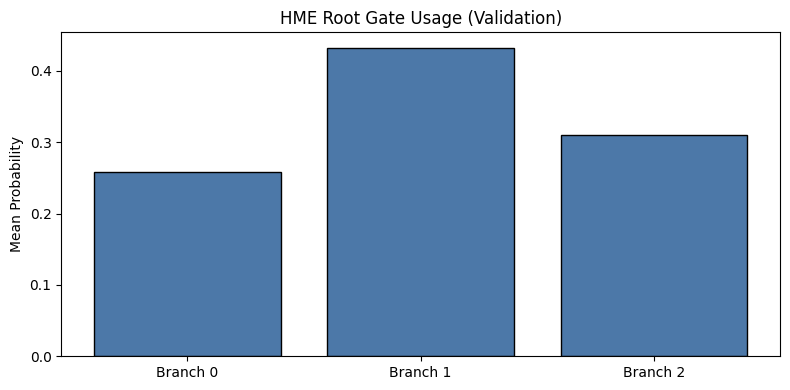

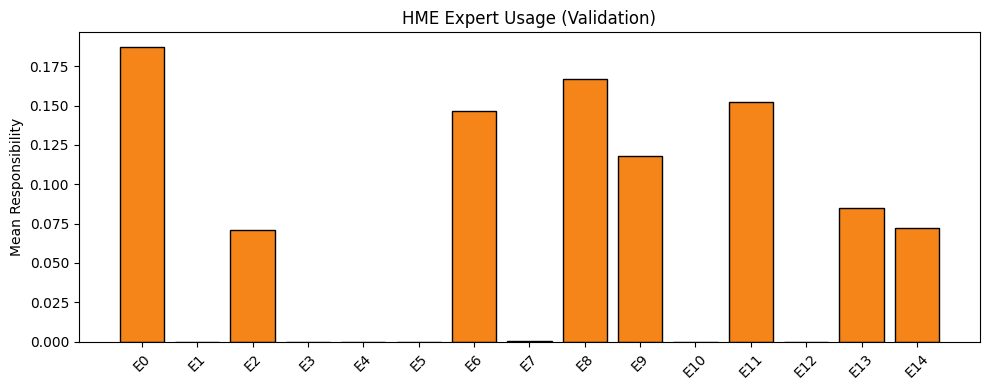

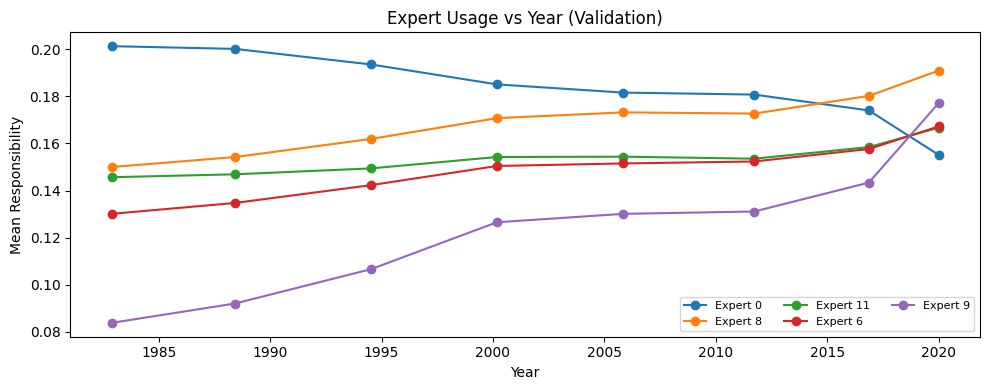

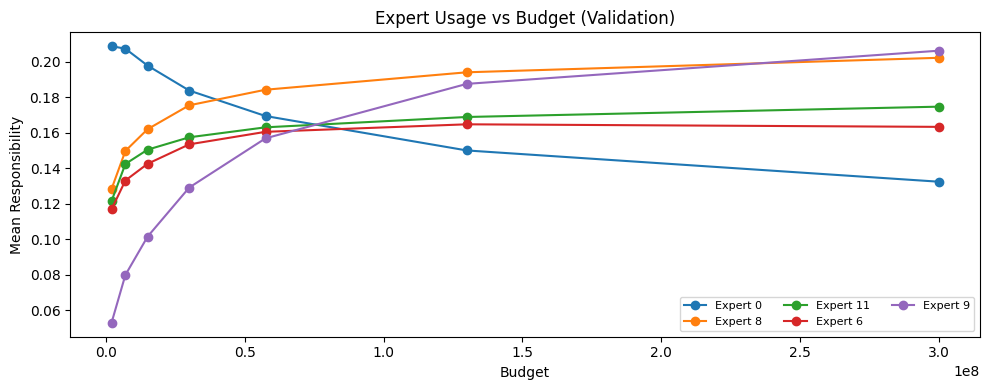

✓ Saved c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\plots\expert_usage_vs_budget.png


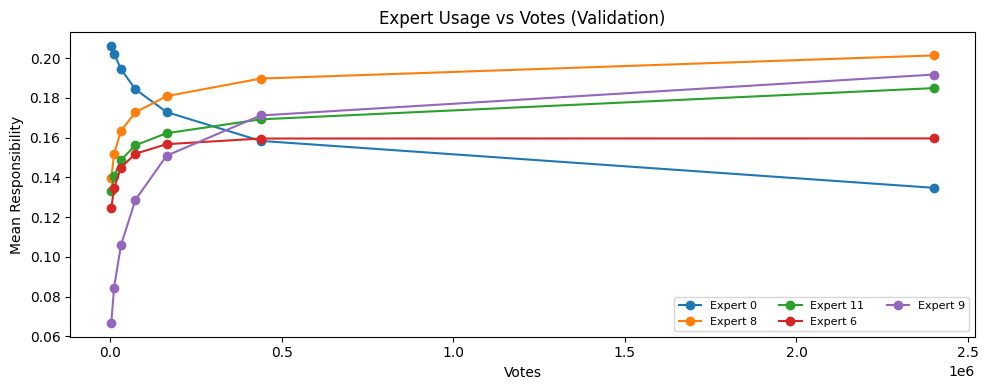

✓ Saved c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\plots\expert_usage_vs_votes.png
✓ Plots saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\plots


In [33]:
plt.figure(figsize=(8, 4))
plt.bar(np.arange(NUM_ROOT), root_usage, color="#4c78a8", edgecolor="black")
plt.xticks(np.arange(NUM_ROOT), [f"Branch {i}" for i in range(NUM_ROOT)])
plt.title("HME Root Gate Usage (Validation)")
plt.ylabel("Mean Probability")
plt.tight_layout()
root_plot_path = PLOTS_DIR / "root_gate_usage.png"
plt.savefig(root_plot_path, dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(np.arange(NUM_ROOT * NUM_LEAF), expert_usage, color="#f58518", edgecolor="black")
plt.xticks(np.arange(NUM_ROOT * NUM_LEAF), [f"E{k}" for k in range(NUM_ROOT * NUM_LEAF)], rotation=45)
plt.title("HME Expert Usage (Validation)")
plt.ylabel("Mean Responsibility")
plt.tight_layout()
expert_plot_path = PLOTS_DIR / "expert_usage.png"
plt.savefig(expert_plot_path, dpi=150)
plt.show()

# Optional: usage vs year (if available)
if "probe_df" in globals() and probe_df is not None and "year" in probe_df.columns:
    year = probe_df["year"].values
    top_experts = np.argsort(expert_usage)[-5:][::-1]
    bins = np.linspace(year.min(), year.max(), 8)
    bin_ids = np.digitize(year, bins)
    plt.figure(figsize=(10, 4))
    for k in top_experts:
        means = []
        centers = []
        for b in range(1, len(bins) + 1):
            mask = bin_ids == b
            if mask.any():
                means.append(val_weights[mask, k].mean())
                centers.append(year[mask].mean())
        plt.plot(centers, means, marker="o", label=f"Expert {k}")
    plt.title("Expert Usage vs Year (Validation)")
    plt.xlabel("Year")
    plt.ylabel("Mean Responsibility")
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    year_plot_path = PLOTS_DIR / "expert_usage_vs_year.png"
    plt.savefig(year_plot_path, dpi=150)
    plt.show()

# Optional: usage vs budget/votes (if available)
if "probe_df" in globals() and probe_df is not None:
    top_experts = np.argsort(expert_usage)[-5:][::-1]

    def _plot_usage_vs_feature(feature_name, title, out_name):
        if feature_name not in probe_df.columns:
            return
        feature = probe_df[feature_name].values
        q = np.quantile(feature, [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0])
        bins = np.unique(q)
        if len(bins) < 4:
            bins = np.linspace(feature.min(), feature.max(), 7)
        bin_ids = np.digitize(feature, bins)

        plt.figure(figsize=(10, 4))
        for k in top_experts:
            means = []
            centers = []
            for b in range(1, len(bins) + 1):
                mask = bin_ids == b
                if mask.any():
                    means.append(val_weights[mask, k].mean())
                    centers.append(np.median(feature[mask]))
            plt.plot(centers, means, marker="o", label=f"Expert {k}")
        plt.title(title)
        plt.xlabel(feature_name.capitalize())
        plt.ylabel("Mean Responsibility")
        plt.legend(ncol=3, fontsize=8)
        plt.tight_layout()
        out_path = PLOTS_DIR / out_name
        plt.savefig(out_path, dpi=150)
        plt.show()
        print(f"✓ Saved {out_path}")

    _plot_usage_vs_feature("budget", "Expert Usage vs Budget (Validation)", "expert_usage_vs_budget.png")
    _plot_usage_vs_feature("votes", "Expert Usage vs Votes (Validation)", "expert_usage_vs_votes.png")

print(f"✓ Plots saved to: {PLOTS_DIR}")

### SECTION YY: BASELINE vs HME (Validation Only)
Train or load a baseline MLP (256→128→64→1) on the same validation split and compare metrics against HME (3×5).

✓ Loaded baseline checkpoint: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\checkpoints\baseline_best.pt
✓ Baseline val predictions saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\predictions\baseline_val_predictions.csv
      Method   Val MSE   Val MAE  MSE Delta (%)  MAE Delta (%)
0   Baseline  1.042319  0.724896        0.00000       0.000000
1  HME (3x5)  1.097700  0.773434        5.31329       6.695938
✓ Baseline vs HME table saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\summaries\baseline_vs_hme.csv


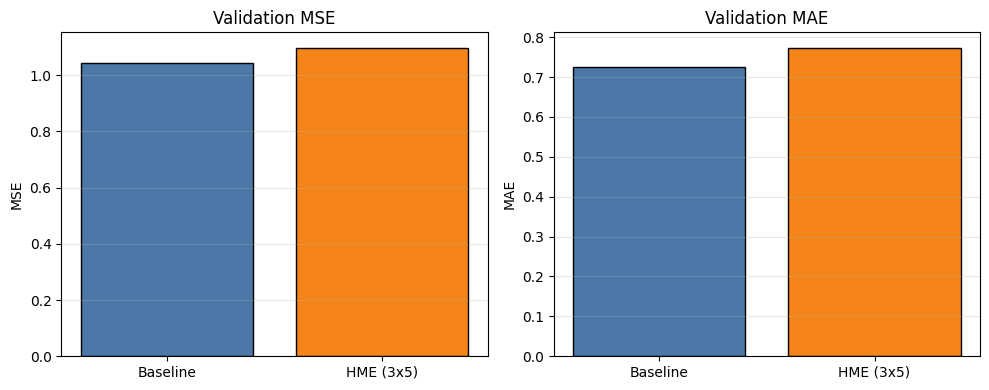

✓ Baseline vs HME plot saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\plots\baseline_vs_hme_val_metrics.png


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Collect full train/val tensors from loaders

def _collect_xy(loader, device):
    xs, ys = [], []
    for xb, yb in loader:
        xs.append(xb.to(device))
        ys.append(yb.to(device).view(-1))
    return torch.cat(xs, dim=0), torch.cat(ys, dim=0)

X_train_full, y_train_full = _collect_xy(_train_loader, _device)
X_val_full, y_val_full = _collect_xy(_val_loader, _device)

class BaselineMLP(nn.Module):
    def __init__(self, in_dim, hidden=(256, 128, 64), dropout=0.1):
        super().__init__()
        layers = []
        dims = [in_dim, *hidden]
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(d_in, d_out))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

baseline_ckpt_path = CHECKPOINTS_DIR / "baseline_best.pt"

baseline = BaselineMLP(input_dim, hidden=(256, 128, 64), dropout=0.1).to(_device)
opt_base = optim.Adam(baseline.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.MSELoss()

if baseline_ckpt_path.exists():
    ckpt = torch.load(baseline_ckpt_path, map_location=_device)
    baseline.load_state_dict(ckpt["model_state"])
    print(f"✓ Loaded baseline checkpoint: {baseline_ckpt_path}")
else:
    best_base_val = float("inf")
    for epoch in range(1, EPOCHS + 1):
        baseline.train()
        for xb, yb in _train_loader:
            xb = xb.to(_device)
            yb = yb.to(_device).view(-1)
            opt_base.zero_grad(set_to_none=True)
            pred = baseline(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(baseline.parameters(), 5.0)
            opt_base.step()

        baseline.eval()
        with torch.no_grad():
            pred_val = baseline(X_val_full)
            val_mse = loss_fn(pred_val, y_val_full).item()
        if val_mse < best_base_val:
            best_base_val = val_mse
            torch.save(
                {"model_state": baseline.state_dict(), "val_mse": val_mse, "epoch": epoch},
                baseline_ckpt_path,
            )
    print(f"✓ Baseline checkpoint saved to: {baseline_ckpt_path}")

# Baseline predictions
baseline.eval()
with torch.no_grad():
    baseline_val_preds = baseline(X_val_full).detach().cpu().numpy()

baseline_val_path = PREDICTIONS_DIR / "baseline_val_predictions.csv"
pd.DataFrame({"y_true": y_val_full.detach().cpu().numpy(), "y_pred": baseline_val_preds}).to_csv(
    baseline_val_path, index=False
)
print(f"✓ Baseline val predictions saved to: {baseline_val_path}")

# HME metrics from best checkpoint predictions
hme_val_mse = mean_squared_error(val_targets, val_preds)
hme_val_mae = mean_absolute_error(val_targets, val_preds)

baseline_val_mse = mean_squared_error(y_val_full.detach().cpu().numpy(), baseline_val_preds)
baseline_val_mae = mean_absolute_error(y_val_full.detach().cpu().numpy(), baseline_val_preds)

compare_df = pd.DataFrame(
    [
        {"Method": "Baseline", "Val MSE": baseline_val_mse, "Val MAE": baseline_val_mae},
        {"Method": "HME (3x5)", "Val MSE": hme_val_mse, "Val MAE": hme_val_mae},
    ]
)

compare_df["MSE Delta (%)"] = (compare_df["Val MSE"] - baseline_val_mse) / baseline_val_mse * 100.0
compare_df["MAE Delta (%)"] = (compare_df["Val MAE"] - baseline_val_mae) / baseline_val_mae * 100.0

compare_path = SUMMARIES_DIR / "baseline_vs_hme.csv"
compare_df.to_csv(compare_path, index=False)
print(compare_df)
print(f"✓ Baseline vs HME table saved to: {compare_path}")

# Plots: MSE/MAE comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(compare_df["Method"], compare_df["Val MSE"], color=["#4c78a8", "#f58518"], edgecolor="black")
axes[0].set_title("Validation MSE")
axes[0].set_ylabel("MSE")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(compare_df["Method"], compare_df["Val MAE"], color=["#4c78a8", "#f58518"], edgecolor="black")
axes[1].set_title("Validation MAE")
axes[1].set_ylabel("MAE")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
bar_plot_path = PLOTS_DIR / "baseline_vs_hme_val_metrics.png"
plt.savefig(bar_plot_path, dpi=150)
plt.show()
print(f"✓ Baseline vs HME plot saved to: {bar_plot_path}")


### Save history and summary
Persist training history, usage stats, and file paths for reproducibility.

In [35]:
history_df = pd.DataFrame(history)
history_path = HISTORIES_DIR / "hme_history.csv"
history_df.to_csv(history_path, index=False)

summary = {
    "best_val_nll": float(best_val_nll),
    "best_checkpoint": str(best_checkpoint_path),
    "root_usage": root_usage.tolist(),
    "expert_usage": expert_usage.tolist(),
    "effective_root_experts": root_eff,
    "effective_leaf_experts": expert_eff,
    "val_pred_path": str(val_pred_path),
    "history_path": str(history_path),
}

summary_path = SUMMARIES_DIR / "hme_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"✓ History saved to: {history_path}")
print(f"✓ Summary saved to: {summary_path}")


✓ History saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\training_histories\hme_history.csv
✓ Summary saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\summaries\hme_summary.json


### HME Phase 2: EM-inspired refinement (gates frozen)
HME admits an EM-style view: an E-step estimates responsibilities (routing), and an M-step refines expert parameters. After Phase 1 routing stabilizes, we **freeze routing** and continue optimizing only the experts (an M-step-like refinement).
Phase 2 fine-tunes only the expert linear heads (15×(64+1) parameters) while keeping the representation and routing fixed, effectively refining a set of weighted linear regressors in the learned 64-D feature space.
**Frozen:** shared backbone encoder, root gate, and all 3 leaf gates (kept in eval mode to disable dropout). **Trainable:** the 15 expert heads only (optionally restricted to the top-K dominant experts).
Optimizer: Adam with $\text{LR} = \text{LEARNING\_RATE} \times 0.01$ and increased expert-only weight decay; best checkpoint saved as **hme_phase2_best.pt** (Phase 1 best saved as **hme_phase1_best.pt**).
Early stopping monitors validation NLL with small patience.

In [36]:
import shutil
from datetime import datetime

# -----------------------------
# Phase 1 checkpoint preservation
# -----------------------------
phase1_src = CHECKPOINTS_DIR / "hme_best.pt"
phase1_dst = CHECKPOINTS_DIR / "hme_phase1_best.pt"

if not phase1_src.exists():
    raise RuntimeError(f"Phase 1 checkpoint not found at {phase1_src}")

if phase1_dst.exists():
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    phase1_dst = CHECKPOINTS_DIR / f"hme_phase1_best_{ts}.pt"

shutil.copy2(phase1_src, phase1_dst)
print(f"✓ Phase 1 checkpoint saved to: {phase1_dst}")

# Save Phase 1 validation predictions (from best HME)
phase1_val_path = PREDICTIONS_DIR / "hme_phase1_val_predictions.csv"
if "val_preds" in globals() and "val_targets" in globals():
    pd.DataFrame({"y_true": val_targets, "y_pred": val_preds}).to_csv(phase1_val_path, index=False)
    print(f"✓ Phase 1 val predictions saved to: {phase1_val_path}")
else:
    # Recompute using Phase 1 checkpoint
    phase1_model = HierarchicalMoE(input_dim=input_dim, hidden_dims=(256, 128, 64), dropout=0.1, num_root=NUM_ROOT, num_leaf=NUM_LEAF).to(_device)
    ckpt = torch.load(phase1_dst, map_location=_device)
    phase1_model.load_state_dict(ckpt["model_state"])
    phase1_model.eval()
    p1_preds = []
    p1_targets = []
    with torch.no_grad():
        for xb, yb in _val_loader:
            xb = xb.to(_device)
            yb = yb.to(_device).view(-1)
            p1_preds.append(phase1_model(xb, temperature=1.0).detach().cpu())
            p1_targets.append(yb.detach().cpu())
    p1_preds = torch.cat(p1_preds, dim=0).numpy()
    p1_targets = torch.cat(p1_targets, dim=0).numpy()
    pd.DataFrame({"y_true": p1_targets, "y_pred": p1_preds}).to_csv(phase1_val_path, index=False)
    print(f"✓ Phase 1 val predictions saved to: {phase1_val_path}")

# -----------------------------
# Phase 2 training (gates frozen, experts only)
# -----------------------------
phase2_model = HierarchicalMoE(input_dim=input_dim, hidden_dims=(256, 128, 64), dropout=0.1, num_root=NUM_ROOT, num_leaf=NUM_LEAF).to(_device)
ckpt = torch.load(phase1_dst, map_location=_device)
phase2_model.load_state_dict(ckpt["model_state"])

# Freeze encoder + gates (default: experts only)
for p in phase2_model.encoder.parameters():
    p.requires_grad = False
for p in phase2_model.root_gate.parameters():
    p.requires_grad = False
for gate in phase2_model.leaf_gates:
    for p in gate.parameters():
        p.requires_grad = False
for p in phase2_model.experts.parameters():
    p.requires_grad = True

# Keep frozen routing deterministic (disable dropout in encoder)
phase2_model.encoder.eval()
phase2_model.root_gate.eval()
for gate in phase2_model.leaf_gates:
    gate.eval()

# Optional: fine-tune only top-K dominant experts
TOPK_EXPERTS = globals().get("TOPK_EXPERTS", None)
if TOPK_EXPERTS is not None:
    if "val_weights" in globals() and val_weights is not None:
        expert_usage_phase1 = np.asarray(val_weights).mean(axis=0)
    else:
        phase1_model = HierarchicalMoE(input_dim=input_dim, hidden_dims=(256, 128, 64), dropout=0.1, num_root=NUM_ROOT, num_leaf=NUM_LEAF).to(_device)
        ckpt = torch.load(phase1_dst, map_location=_device)
        phase1_model.load_state_dict(ckpt["model_state"])
        phase1_model.eval()
        w_list = []
        with torch.no_grad():
            for xb, _ in _val_loader:
                xb = xb.to(_device)
                _, _, _, _, w = phase1_model(xb, temperature=1.0, return_all=True)
                w_list.append(w.detach().cpu())
        expert_usage_phase1 = torch.cat(w_list, dim=0).mean(dim=0).numpy()

    topk = int(TOPK_EXPERTS)
    topk_idx = np.argsort(expert_usage_phase1)[-topk:]
    for idx, expert in enumerate(phase2_model.experts):
        requires = idx in set(topk_idx.tolist())
        for p in expert.parameters():
            p.requires_grad = requires

trainable_params = [p for p in phase2_model.parameters() if p.requires_grad]

PHASE2_EPOCHS = 10
PHASE2_LR = LEARNING_RATE * 0.01
PHASE2_WEIGHT_DECAY = WEIGHT_DECAY * 10
PHASE2_PATIENCE = 2

opt_phase2 = optim.Adam(trainable_params, lr=PHASE2_LR, weight_decay=PHASE2_WEIGHT_DECAY)

# -----------------------------
# Phase-2 validation (freeze + optimizer + routing invariance)
# -----------------------------
name_to_param = {n: p for n, p in phase2_model.named_parameters()}

gate_params = [(n, p) for n, p in name_to_param.items() if "gate" in n]
expert_params = [(n, p) for n, p in name_to_param.items() if n.startswith("experts")]
backbone_params = [(n, p) for n, p in name_to_param.items() if n.startswith("encoder")]

if not gate_params:
    raise RuntimeError("Phase-2 validation failed: no gate parameters found by name.")
if not expert_params:
    raise RuntimeError("Phase-2 validation failed: no expert parameters found by name.")

if not all(not p.requires_grad for _, p in gate_params):
    raise RuntimeError("Phase-2 validation failed: some gate parameters are not frozen.")
if TOPK_EXPERTS is None and not all(p.requires_grad for _, p in expert_params):
    raise RuntimeError("Phase-2 validation failed: some expert parameters are frozen.")
if not all(not p.requires_grad for _, p in backbone_params):
    raise RuntimeError("Phase-2 validation failed: backbone (encoder) is not frozen.")

opt_param_ids = {id(p) for g in opt_phase2.param_groups for p in g["params"]}
if not all(p.requires_grad for g in opt_phase2.param_groups for p in g["params"]):
    raise RuntimeError("Phase-2 validation failed: optimizer contains non-trainable parameters.")

for n, p in gate_params + backbone_params:
    if id(p) in opt_param_ids:
        raise RuntimeError(f"Phase-2 validation failed: frozen param in optimizer: {n}")

phase2_history = defaultdict(list)
best_phase2_val = float("inf")
phase2_ckpt_path = CHECKPOINTS_DIR / "hme_phase2_best.pt"

phase2_validation_done = False
early_stop_count = 0

for epoch in range(1, PHASE2_EPOCHS + 1):
    phase2_model.train()
    phase2_model.encoder.eval()
    phase2_model.root_gate.eval()
    for gate in phase2_model.leaf_gates:
        gate.eval()
    train_nll_sum = 0.0
    n_train = 0

    for xb, yb in _train_loader:
        xb = xb.to(_device)
        yb = yb.to(_device).view(-1)
        opt_phase2.zero_grad(set_to_none=True)

        # Routing invariance check (epoch 1, once, before first optimizer step)
        if epoch == 1 and not phase2_validation_done:
            xb_val, yb_val = next(iter(_val_loader))
            xb_val = xb_val.to(_device)
            yb_val = yb_val.to(_device).view(-1)
            with torch.no_grad():
                _, root_before, leaf_before, _, w_before = phase2_model(xb_val, temperature=1.0, return_all=True)

        _, _, _, mu, weights_flat = phase2_model(xb, temperature=1.0, return_all=True)
        mu_flat = mu.reshape(mu.shape[0], -1)
        nll = gaussian_mixture_nll(yb, mu_flat, weights_flat, sigma=SIGMA)
        nll.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, 5.0)
        opt_phase2.step()

        if epoch == 1 and not phase2_validation_done:
            with torch.no_grad():
                _, root_after, leaf_after, _, w_after = phase2_model(xb_val, temperature=1.0, return_all=True)
            max_root = (root_after - root_before).abs().max().item()
            max_leaf = (leaf_after - leaf_before).abs().max().item()
            max_w = (w_after - w_before).abs().max().item()
            if max(max_root, max_leaf, max_w) >= 1e-7:
                raise RuntimeError("Phase-2 validation failed: routing changed after expert update.")
            print("Phase-2 validation OK: routing frozen, experts updating.")
            phase2_validation_done = True

        bs = yb.shape[0]
        train_nll_sum += nll.item() * bs
        n_train += bs

    train_nll = train_nll_sum / max(1, n_train)

    phase2_model.eval()
    val_nll_sum = 0.0
    val_mse_sum = 0.0
    val_mae_sum = 0.0
    n_val = 0

    with torch.no_grad():
        for xb, yb in _val_loader:
            xb = xb.to(_device)
            yb = yb.to(_device).view(-1)
            y_hat, _, _, mu, weights_flat = phase2_model(xb, temperature=1.0, return_all=True)
            mu_flat = mu.reshape(mu.shape[0], -1)
            nll = gaussian_mixture_nll(yb, mu_flat, weights_flat, sigma=SIGMA)
            mse = torch.mean((y_hat - yb) ** 2)
            mae = torch.mean(torch.abs(y_hat - yb))

            bs = yb.shape[0]
            val_nll_sum += nll.item() * bs
            val_mse_sum += mse.item() * bs
            val_mae_sum += mae.item() * bs
            n_val += bs

    val_nll = val_nll_sum / max(1, n_val)
    val_mse = val_mse_sum / max(1, n_val)
    val_mae = val_mae_sum / max(1, n_val)

    phase2_history["epoch"].append(epoch)
    phase2_history["train_nll"].append(train_nll)
    phase2_history["val_nll"].append(val_nll)
    phase2_history["val_mse"].append(val_mse)
    phase2_history["val_mae"].append(val_mae)

    if val_nll < best_phase2_val:
        best_phase2_val = val_nll
        early_stop_count = 0
        torch.save(
            {"model_state": phase2_model.state_dict(), "epoch": epoch, "val_nll": val_nll},
            phase2_ckpt_path,
        )
    else:
        early_stop_count += 1
        if early_stop_count >= PHASE2_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch} (patience={PHASE2_PATIENCE}).")
            break

    if epoch == 1 or epoch % 5 == 0 or epoch == PHASE2_EPOCHS:
        print(
            f"Phase2 Epoch {epoch:03d}/{PHASE2_EPOCHS} | train_nll={train_nll:.4f} | "
            f"val_nll={val_nll:.4f} | val_mse={val_mse:.4f} | val_mae={val_mae:.4f}"
        )

print(f"✓ Phase 2 checkpoint saved to: {phase2_ckpt_path}")

phase2_hist_path = HISTORIES_DIR / "hme_phase2_history.csv"
pd.DataFrame(phase2_history).to_csv(phase2_hist_path, index=False)
print(f"✓ Phase 2 history saved to: {phase2_hist_path}")

# Phase 2 validation predictions
ckpt = torch.load(phase2_ckpt_path, map_location=_device)
phase2_model.load_state_dict(ckpt["model_state"])
phase2_model.eval()

p2_preds = []
p2_targets = []
with torch.no_grad():
    for xb, yb in _val_loader:
        xb = xb.to(_device)
        yb = yb.to(_device).view(-1)
        p2_preds.append(phase2_model(xb, temperature=1.0).detach().cpu())
        p2_targets.append(yb.detach().cpu())

p2_preds = torch.cat(p2_preds, dim=0).numpy()
p2_targets = torch.cat(p2_targets, dim=0).numpy()

phase2_val_path = PREDICTIONS_DIR / "hme_phase2_val_predictions.csv"
pd.DataFrame({"y_true": p2_targets, "y_pred": p2_preds}).to_csv(phase2_val_path, index=False)
print(f"✓ Phase 2 val predictions saved to: {phase2_val_path}")

✓ Phase 1 checkpoint saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\checkpoints\hme_phase1_best_20260119_135525.pt
✓ Phase 1 val predictions saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\predictions\hme_phase1_val_predictions.csv
Phase-2 validation OK: routing frozen, experts updating.
Phase2 Epoch 001/10 | train_nll=1.4585 | val_nll=1.4752 | val_mse=1.0940 | val_mae=0.7704
Phase2 Epoch 005/10 | train_nll=1.4336 | val_nll=1.4534 | val_mse=1.0810 | val_mae=0.7587
Phase2 Epoch 010/10 | train_nll=1.4125 | val_nll=1.4358 | val_mse=1.0733 | val_mae=0.7506
✓ Phase 2 checkpoint saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\checkpoints\hme_phase2_best.pt
✓ Phase 2 history saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\training_histories\hme_phase2_history.csv
✓ Phase 2 val predictions saved to: c:\Users\Len

### Validation comparison: baseline vs HME Phase 1/2
Compare validation metrics for the baseline, HME Phase 1, and HME Phase 2 trained with the chosen hyperparameters.

        Method   Val MSE   Val MAE  MSE Delta (%)  MAE Delta (%)
0     Baseline  1.042319  0.724896       0.000000       0.000000
1  HME Phase 1  1.097700  0.773434       5.313290       6.695938
2  HME Phase 2  1.073268  0.750616       2.969291       3.548196
✓ Validation comparison saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\summaries\val_comparison_baseline_hme_phase1_phase2.csv


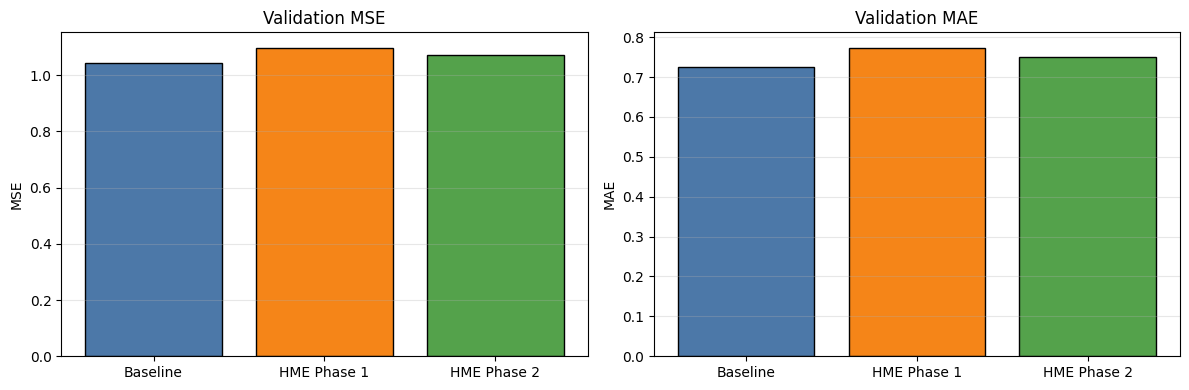

✓ Validation comparison plot saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\plots\val_baseline_vs_hme_phase1_phase2.png


In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensure we have full val tensors
if "_collect_xy" not in globals():
    def _collect_xy(loader, device):
        xs, ys = [], []
        for xb, yb in loader:
            xs.append(xb.to(device))
            ys.append(yb.to(device).view(-1))
        return torch.cat(xs, dim=0), torch.cat(ys, dim=0)

X_val_full, y_val_full = _collect_xy(_val_loader, _device)

# Baseline model
baseline_ckpt_path = CHECKPOINTS_DIR / "baseline_best.pt"
baseline_model = BaselineMLP(X_val_full.shape[1], hidden=(256, 128, 64), dropout=0.1).to(_device)
if baseline_ckpt_path.exists():
    ckpt = torch.load(baseline_ckpt_path, map_location=_device)
    baseline_model.load_state_dict(ckpt["model_state"])
elif "baseline" in globals():
    baseline_model = baseline
baseline_model.eval()

# HME Phase 1
hme_phase1 = HierarchicalMoE(input_dim=X_val_full.shape[1], hidden_dims=(256, 128, 64), dropout=0.1, num_root=NUM_ROOT, num_leaf=NUM_LEAF).to(_device)
ckpt = torch.load(phase1_dst, map_location=_device)
hme_phase1.load_state_dict(ckpt["model_state"])
hme_phase1.eval()

# HME Phase 2
hme_phase2 = HierarchicalMoE(input_dim=X_val_full.shape[1], hidden_dims=(256, 128, 64), dropout=0.1, num_root=NUM_ROOT, num_leaf=NUM_LEAF).to(_device)
ckpt = torch.load(phase2_ckpt_path, map_location=_device)
hme_phase2.load_state_dict(ckpt["model_state"])
hme_phase2.eval()

with torch.no_grad():
    baseline_val_pred = baseline_model(X_val_full).detach().cpu().numpy()
    hme1_val_pred = hme_phase1(X_val_full, temperature=1.0).detach().cpu().numpy()
    hme2_val_pred = hme_phase2(X_val_full, temperature=1.0).detach().cpu().numpy()

y_val_np_local = y_val_full.detach().cpu().numpy()

rows = [
    {"Method": "Baseline", "Val MSE": mean_squared_error(y_val_np_local, baseline_val_pred), "Val MAE": mean_absolute_error(y_val_np_local, baseline_val_pred)},
    {"Method": "HME Phase 1", "Val MSE": mean_squared_error(y_val_np_local, hme1_val_pred), "Val MAE": mean_absolute_error(y_val_np_local, hme1_val_pred)},
    {"Method": "HME Phase 2", "Val MSE": mean_squared_error(y_val_np_local, hme2_val_pred), "Val MAE": mean_absolute_error(y_val_np_local, hme2_val_pred)},
]

val_compare_df = pd.DataFrame(rows)

baseline_val_mse = val_compare_df.loc[val_compare_df["Method"] == "Baseline", "Val MSE"].values[0]
baseline_val_mae = val_compare_df.loc[val_compare_df["Method"] == "Baseline", "Val MAE"].values[0]
val_compare_df["MSE Delta (%)"] = (val_compare_df["Val MSE"] - baseline_val_mse) / baseline_val_mse * 100.0
val_compare_df["MAE Delta (%)"] = (val_compare_df["Val MAE"] - baseline_val_mae) / baseline_val_mae * 100.0

val_compare_path = SUMMARIES_DIR / "val_comparison_baseline_hme_phase1_phase2.csv"
val_compare_df.to_csv(val_compare_path, index=False)
print(val_compare_df)
print(f"✓ Validation comparison saved to: {val_compare_path}")

# Plot comparison
colors = ["#4c78a8", "#f58518", "#54a24b"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(val_compare_df["Method"], val_compare_df["Val MSE"], color=colors, edgecolor="black")
axes[0].set_title("Validation MSE")
axes[0].set_ylabel("MSE")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(val_compare_df["Method"], val_compare_df["Val MAE"], color=colors, edgecolor="black")
axes[1].set_title("Validation MAE")
axes[1].set_ylabel("MAE")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
val_plot_path = PLOTS_DIR / "val_baseline_vs_hme_phase1_phase2.png"
plt.savefig(val_plot_path, dpi=150)
plt.show()
print(f"✓ Validation comparison plot saved to: {val_plot_path}")

### Saved checkpoints
- **baseline_best.pt** — baseline MLP.
- **hme_phase1_best.pt** — best Phase 1 HME (before Phase 2).
- **hme_phase2_best.pt** — best Phase 2 HME (after expert-only refinement).
Test comparisons are run only in the final section.

### FINAL COMPARISON ON TEST: Baseline vs HME Phase 1 vs HME Phase 2
Evaluate on the held-out test set once, and compare the baseline, HME Phase 1, and HME Phase 2 trained with the chosen hyperparameters.

FINAL COMPARISON ON TEST: Baseline vs HME Phase 1 vs HME Phase 2
✓ Baseline test predictions saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\predictions\baseline_test_predictions.csv
✓ HME Phase 1 test predictions saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\predictions\hme_phase1_test_predictions.csv
✓ HME Phase 2 test predictions saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\predictions\hme_phase2_test_predictions.csv
        Method  Test MSE  Test MAE
0     Baseline  1.011935  0.702886
1  HME Phase 1  1.056098  0.744135
2  HME Phase 2  1.039497  0.723080
✓ Test comparison saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\summaries\test_comparison_baseline_hme_phase1_phase2.csv


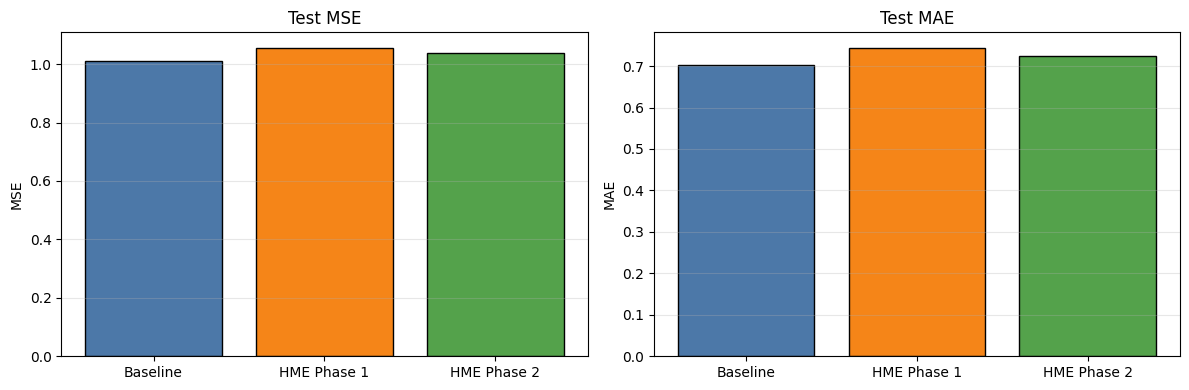

✓ Test comparison plot saved to: c:\Users\Lenovo\Desktop\deep_learning\Project\RateAhead\notebooks\artifacts\hme_3x5\plots\test_baseline_vs_hme_phase1_phase2.png


In [38]:
print("="*100)
print("FINAL COMPARISON ON TEST: Baseline vs HME Phase 1 vs HME Phase 2")
print("="*100)

# Load test split only here
from data.encode_features import prepare_features

data_dir = Path(globals().get("ALL_FEATURES_DIR", PROJECT_ROOT / "data" / "processed" / "all_features"))
train_df = pd.read_csv(data_dir / "train.csv")
val_df = pd.read_csv(data_dir / "val.csv")
test_df = pd.read_csv(data_dir / "test.csv")

X_train_np, X_val_np, X_test_np, y_train_np, y_val_np, y_test_np, _art = prepare_features(train_df, val_df, test_df)
X_test_t = torch.from_numpy(X_test_np).to(_device)
y_test_t = torch.from_numpy(y_test_np).to(_device)

# Baseline model
baseline_ckpt_path = CHECKPOINTS_DIR / "baseline_best.pt"
baseline_model = BaselineMLP(X_test_np.shape[1], hidden=(256, 128, 64), dropout=0.1).to(_device)

if baseline_ckpt_path.exists():
    ckpt = torch.load(baseline_ckpt_path, map_location=_device)
    baseline_model.load_state_dict(ckpt["model_state"])
    baseline_model.eval()
else:
    if "baseline" in globals():
        baseline_model = baseline
        baseline_model.eval()
    else:
        # Fallback: quick train using existing loaders
        opt_base = optim.Adam(baseline_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        loss_fn = nn.MSELoss()
        best_base_val = float("inf")
        for epoch in range(1, min(20, EPOCHS) + 1):
            baseline_model.train()
            for xb, yb in _train_loader:
                xb = xb.to(_device)
                yb = yb.to(_device).view(-1)
                opt_base.zero_grad(set_to_none=True)
                pred = baseline_model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 5.0)
                opt_base.step()
            baseline_model.eval()
            with torch.no_grad():
                pred_val = baseline_model(X_val_full)
                val_mse = loss_fn(pred_val, y_val_full).item()
            if val_mse < best_base_val:
                best_base_val = val_mse
                torch.save({"model_state": baseline_model.state_dict(), "val_mse": val_mse}, baseline_ckpt_path)
        print(f"✓ Baseline checkpoint saved to: {baseline_ckpt_path}")

# HME Phase 1
hme_phase1 = HierarchicalMoE(input_dim=X_test_np.shape[1], hidden_dims=(256, 128, 64), dropout=0.1, num_root=NUM_ROOT, num_leaf=NUM_LEAF).to(_device)
ckpt = torch.load(phase1_dst, map_location=_device)
hme_phase1.load_state_dict(ckpt["model_state"])
hme_phase1.eval()

# HME Phase 2
hme_phase2 = HierarchicalMoE(input_dim=X_test_np.shape[1], hidden_dims=(256, 128, 64), dropout=0.1, num_root=NUM_ROOT, num_leaf=NUM_LEAF).to(_device)
ckpt = torch.load(phase2_ckpt_path, map_location=_device)
hme_phase2.load_state_dict(ckpt["model_state"])
hme_phase2.eval()

with torch.no_grad():
    baseline_test_pred = baseline_model(X_test_t).detach().cpu().numpy()
    hme1_test_pred = hme_phase1(X_test_t, temperature=1.0).detach().cpu().numpy()
    hme2_test_pred = hme_phase2(X_test_t, temperature=1.0).detach().cpu().numpy()

    y_test_np_local = y_test_t.detach().cpu().numpy()

# Save test predictions
baseline_test_path = PREDICTIONS_DIR / "baseline_test_predictions.csv"
pd.DataFrame({"y_true": y_test_np_local, "y_pred": baseline_test_pred, "abs_error": np.abs(baseline_test_pred - y_test_np_local)}).to_csv(
    baseline_test_path, index=False
)

hme1_test_path = PREDICTIONS_DIR / "hme_phase1_test_predictions.csv"
pd.DataFrame({"y_true": y_test_np_local, "y_pred": hme1_test_pred, "abs_error": np.abs(hme1_test_pred - y_test_np_local)}).to_csv(
    hme1_test_path, index=False
)

hme2_test_path = PREDICTIONS_DIR / "hme_phase2_test_predictions.csv"
pd.DataFrame({"y_true": y_test_np_local, "y_pred": hme2_test_pred, "abs_error": np.abs(hme2_test_pred - y_test_np_local)}).to_csv(
    hme2_test_path, index=False
)

print(f"✓ Baseline test predictions saved to: {baseline_test_path}")
print(f"✓ HME Phase 1 test predictions saved to: {hme1_test_path}")
print(f"✓ HME Phase 2 test predictions saved to: {hme2_test_path}")

# Metrics + comparison table
rows = [
    {"Method": "Baseline", "Test MSE": mean_squared_error(y_test_np_local, baseline_test_pred), "Test MAE": mean_absolute_error(y_test_np_local, baseline_test_pred)},
    {"Method": "HME Phase 1", "Test MSE": mean_squared_error(y_test_np_local, hme1_test_pred), "Test MAE": mean_absolute_error(y_test_np_local, hme1_test_pred)},
    {"Method": "HME Phase 2", "Test MSE": mean_squared_error(y_test_np_local, hme2_test_pred), "Test MAE": mean_absolute_error(y_test_np_local, hme2_test_pred)},
]

comparison_df = pd.DataFrame(rows)

comparison_path = SUMMARIES_DIR / "test_comparison_baseline_hme_phase1_phase2.csv"
comparison_df.to_csv(comparison_path, index=False)
print(comparison_df)
print(f"✓ Test comparison saved to: {comparison_path}")

# Plot comparison
colors = ["#4c78a8", "#f58518", "#54a24b"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(comparison_df["Method"], comparison_df["Test MSE"], color=colors, edgecolor="black")
axes[0].set_title("Test MSE")
axes[0].set_ylabel("MSE")
axes[0].grid(True, axis="y", alpha=0.3)

axes[1].bar(comparison_df["Method"], comparison_df["Test MAE"], color=colors, edgecolor="black")
axes[1].set_title("Test MAE")
axes[1].set_ylabel("MAE")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plot_path = PLOTS_DIR / "test_baseline_vs_hme_phase1_phase2.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"✓ Test comparison plot saved to: {plot_path}")